# Домашнее задание 5

Поиск и обработка выбросов, кодирование категориальных признаков в датасете заявок на кредит.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

## Подготовка данных: заполнение пропусков (как в ДЗ 4)

Беру исходный файл и повторяю обработку пропусков из ДЗ 4, чтобы ноутбук запускался сам по себе:

- `LoanAmount` — медиана (распределение сильно скошено);
- `Loan_Amount_Term` — мода (дискретный признак со стандартными сроками);
- категориальные признаки (`Gender`, `Married`, `Dependents`, `Self_Employed`, `Credit_History`) — мода.

In [2]:
raw = pd.read_csv("loan_prediction_dataset.csv")

fill_values = {
    "LoanAmount": raw["LoanAmount"].median(),
    "Loan_Amount_Term": raw["Loan_Amount_Term"].mode()[0],
}
for col in ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]:
    fill_values[col] = raw[col].mode()[0]

df = raw.fillna(value=fill_values)

print("Размер:", df.shape)
print("Пропусков:", df.isna().sum().sum())
df.head()

Размер: (614, 13)
Пропусков: 0


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Задание 1. Поиск выбросов двумя способами (4 балла)

- **IQR-правило.** Выброс — значение за пределами `[Q1 − 1.5·IQR; Q3 + 1.5·IQR]`, где `IQR = Q3 − Q1`. Границы строятся по квартилям, поэтому сами выбросы на них почти не влияют.
- **Метод стандартного отклонения.** Выброс — значение, которое отстоит от среднего больше чем на 3 стандартных отклонения: за пределами `[mean − 3·std; mean + 3·std]`. Для нормального распределения за эти границы попадает около 0.3 % значений.

Пишу по функции на каждый метод. Обе возвращают маску выбросов и границы.

In [3]:
def iqr_outliers(series: pd.Series, k: float = 1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper), lower, upper


def std_outliers(series: pd.Series, n_std: float = 3):
    mean, std = series.mean(), series.std()
    lower, upper = mean - n_std * std, mean + n_std * std
    return (series < lower) | (series > upper), lower, upper

In [4]:
target_cols = ["ApplicantIncome", "LoanAmount"]

masks = {}
summary = []
for col in target_cols:
    iqr_mask, iqr_low, iqr_high = iqr_outliers(df[col])
    std_mask, std_low, std_high = std_outliers(df[col])
    masks[col] = {"IQR": iqr_mask, "STD": std_mask}
    summary.append({
        "признак": col,
        "IQR: нижняя граница": iqr_low,
        "IQR: верхняя граница": iqr_high,
        "IQR: выбросов": iqr_mask.sum(),
        "STD: нижняя граница": std_low,
        "STD: верхняя граница": std_high,
        "STD: выбросов": std_mask.sum(),
    })

pd.DataFrame(summary).set_index("признак").round(1).T

признак,ApplicantIncome,LoanAmount
IQR: нижняя граница,-1498.8,3.5
IQR: верхняя граница,10171.2,261.5
IQR: выбросов,50.0,41.0
STD: нижняя граница,-12923.7,-106.6
STD: верхняя граница,23730.6,398.1
STD: выбросов,8.0,15.0


Нижние границы у обоих методов отрицательные или очень маленькие, а доход и сумма кредита не бывают отрицательными, поэтому все найденные выбросы — это слишком большие значения. Сами списки выбросов:

In [5]:
for col in target_cols:
    for method in ["IQR", "STD"]:
        values = df.loc[masks[col][method], col].sort_values()
        print(f"{col}, {method}: {len(values)} шт. -> {values.tolist()}")
    print()

ApplicantIncome, IQR: 50 шт. -> [10408, 10416, 10513, 10750, 10833, 11000, 11146, 11250, 11417, 11500, 11757, 12000, 12000, 12500, 12841, 12876, 13262, 13650, 14583, 14583, 14683, 14866, 14880, 14999, 15000, 15759, 16120, 16250, 16525, 16666, 16667, 16692, 17263, 17500, 18165, 18333, 19484, 19730, 20166, 20233, 20667, 20833, 23803, 33846, 37719, 39147, 39999, 51763, 63337, 81000]
ApplicantIncome, STD: 8 шт. -> [23803, 33846, 37719, 39147, 39999, 51763, 63337, 81000]

LoanAmount, IQR: 41 шт. -> [265.0, 267.0, 275.0, 275.0, 275.0, 279.0, 280.0, 286.0, 290.0, 292.0, 296.0, 300.0, 304.0, 308.0, 311.0, 312.0, 315.0, 320.0, 324.0, 330.0, 349.0, 350.0, 360.0, 370.0, 376.0, 380.0, 400.0, 405.0, 436.0, 480.0, 480.0, 480.0, 490.0, 495.0, 496.0, 500.0, 570.0, 600.0, 600.0, 650.0, 700.0]
LoanAmount, STD: 15 шт. -> [400.0, 405.0, 436.0, 480.0, 480.0, 480.0, 490.0, 495.0, 496.0, 500.0, 570.0, 600.0, 600.0, 650.0, 700.0]



## Задание 2. Сравнение списков выбросов (4 балла)

Для каждого признака сравниваю множества индексов строк: найденные обоими методами, только IQR и только STD.

In [6]:
comparison = []
for col in target_cols:
    iqr_idx = set(df.index[masks[col]["IQR"]])
    std_idx = set(df.index[masks[col]["STD"]])
    comparison.append({
        "признак": col,
        "IQR": len(iqr_idx),
        "STD": len(std_idx),
        "оба метода": len(iqr_idx & std_idx),
        "только IQR": len(iqr_idx - std_idx),
        "только STD": len(std_idx - iqr_idx),
        "STD входит в IQR": std_idx <= iqr_idx,
    })

pd.DataFrame(comparison).set_index("признак")

,IQR,STD,оба метода,только IQR,только STD,STD входит в IQR
признак,,,,,,
ApplicantIncome,50,8,8,42,0,True
LoanAmount,41,15,15,26,0,True


Смотрю, какие значения нашёл только IQR, и как меняются среднее и стандартное отклонение, если убрать эти большие значения.

In [7]:
for col in target_cols:
    only_iqr = df.loc[masks[col]["IQR"] & ~masks[col]["STD"], col]
    print(f"{col}: только IQR — от {only_iqr.min()} до {only_iqr.max()}")

    without_iqr_outliers = df.loc[~masks[col]["IQR"], col]
    print(f"  mean/std по всем данным:         {df[col].mean():.1f} / {df[col].std():.1f}")
    print(f"  mean/std без выбросов по IQR:    {without_iqr_outliers.mean():.1f} / {without_iqr_outliers.std():.1f}")
    print(f"  асимметрия: {df[col].skew():.2f}")
    print()

ApplicantIncome: только IQR — от 10408 до 20833
  mean/std по всем данным:         5403.5 / 6109.0
  mean/std без выбросов по IQR:    4124.7 / 1927.0
  асимметрия: 6.54

LoanAmount: только IQR — от 265.0 до 380.0
  mean/std по всем данным:         145.8 / 84.1
  mean/std без выбросов по IQR:    128.5 / 46.4
  асимметрия: 2.74



**Вывод:**

- Для `ApplicantIncome` IQR нашёл 50 выбросов, STD — 8. Для `LoanAmount` IQR нашёл 41, STD — 15.
- В обоих признаках все выбросы по STD входят в список IQR, то есть пересечение совпадает со списком STD. Значений, найденных только методом STD, нет. Расхождение состоит из «умеренных» выбросов, которые нашёл только IQR: доходы примерно от 10.4 до 20.8 тыс. и суммы кредита от 265 до 380.

**Почему методы расходятся:**

1. **Асимметрия распределений.** Правило 3σ рассчитано на примерно нормальное распределение. Здесь оба признака сильно скошены вправо (асимметрия 6.5 и 2.7), поэтому длинный правый хвост — это «норма» для данных, и STD считает выбросами только самые экстремальные значения.
2. **Выбросы раздувают сами границы STD (эффект маскировки).** Среднее и стандартное отклонение чувствительны к большим значениям: для `ApplicantIncome` std по всем данным около 6109, а без выбросов по IQR — около 1927. Из-за этого верхняя граница STD (≈ 23 731) уходит далеко вправо, и умеренные выбросы оказываются внутри неё.
3. **IQR устойчив к выбросам.** Квартили почти не зависят от крайних значений, поэтому граница IQR (≈ 10 171 для дохода) остаётся близко к основной массе данных и отсекает больше наблюдений.

Итого: IQR строже и лучше подходит для скошенных данных, STD находит только экстремальные значения.

## Задание 3. Визуальное подтверждение выбросов (3 балла)

Строю boxplot (точки за усами — выбросы по IQR) и гистограммы с границами обоих методов.

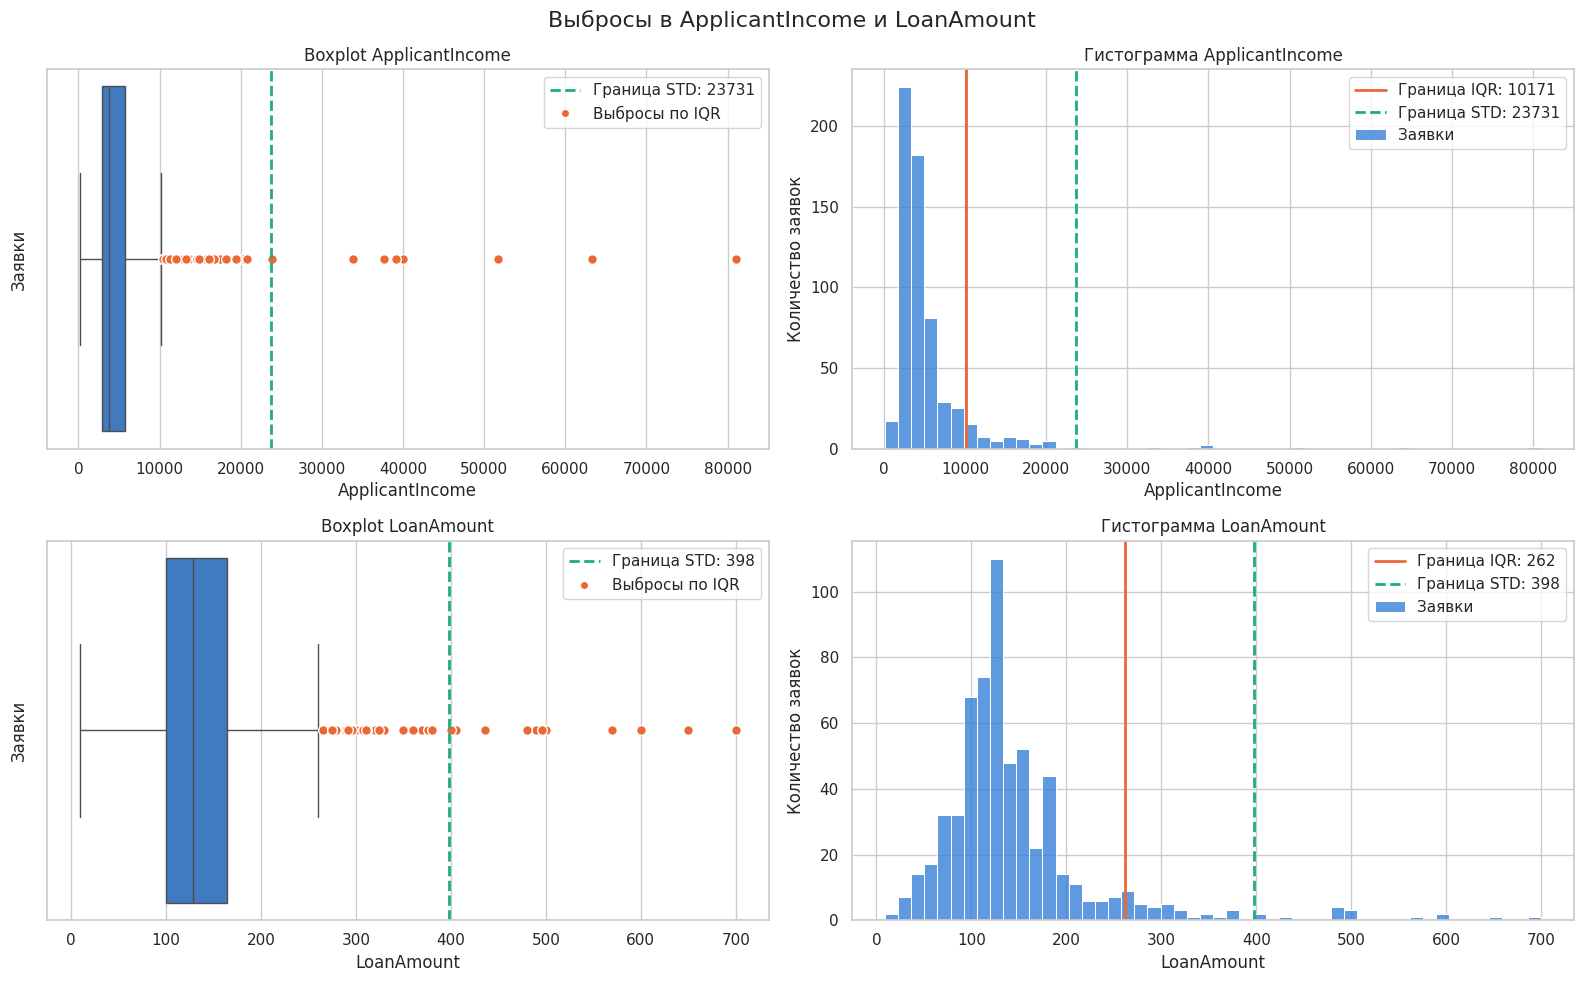

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, col in enumerate(target_cols):
    _, iqr_low, iqr_high = iqr_outliers(df[col])
    _, std_low, std_high = std_outliers(df[col])

    sns.boxplot(x=df[col], color=BLUE, width=0.5, ax=axes[row, 0],
                flierprops={"marker": "o", "markerfacecolor": ORANGE, "markeredgecolor": "white", "markersize": 7})
    axes[row, 0].axvline(std_high, color=AQUA, linestyle="--", linewidth=2, label=f"Граница STD: {std_high:.0f}")
    axes[row, 0].plot([], [], marker="o", linestyle="", markerfacecolor=ORANGE, markeredgecolor="white",
                      label="Выбросы по IQR")
    axes[row, 0].set(title=f"Boxplot {col}", xlabel=col, ylabel="Заявки")
    axes[row, 0].legend(loc="upper right")

    sns.histplot(df[col], bins=50, color=BLUE, label="Заявки", ax=axes[row, 1])
    axes[row, 1].axvline(iqr_high, color=ORANGE, linewidth=2, label=f"Граница IQR: {iqr_high:.0f}")
    axes[row, 1].axvline(std_high, color=AQUA, linestyle="--", linewidth=2, label=f"Граница STD: {std_high:.0f}")
    axes[row, 1].set(title=f"Гистограмма {col}", xlabel=col, ylabel="Количество заявок")
    axes[row, 1].legend(loc="upper right")

fig.suptitle("Выбросы в ApplicantIncome и LoanAmount", fontsize=16)
fig.tight_layout()
plt.show()

Чтобы проверить, что большие значения — это хвост распределения, а не отдельные ошибки, строю те же гистограммы в логарифмическом масштабе и диаграмму рассеяния дохода и суммы кредита.

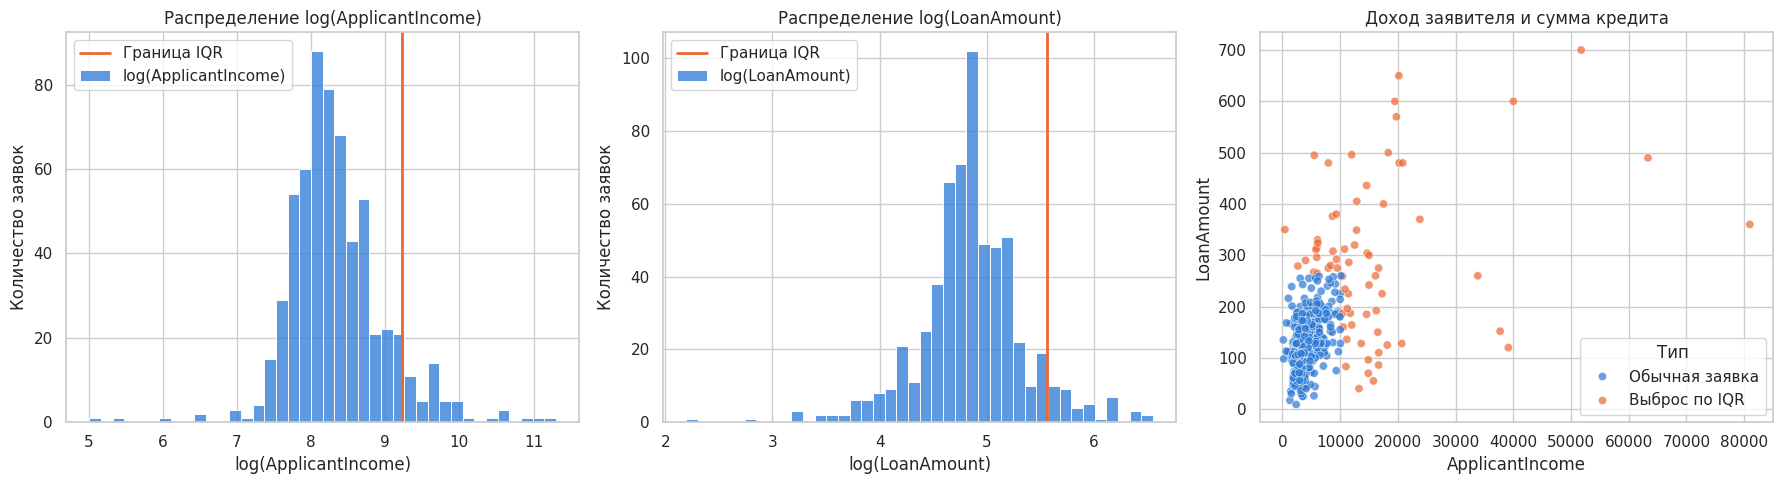

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes[:2], target_cols):
    sns.histplot(np.log(df[col]), bins=40, color=BLUE, label=f"log({col})", ax=ax)
    ax.axvline(np.log(iqr_outliers(df[col])[2]), color=ORANGE, linewidth=2, label="Граница IQR")
    ax.set(title=f"Распределение log({col})", xlabel=f"log({col})", ylabel="Количество заявок")
    ax.legend()

is_outlier = masks["ApplicantIncome"]["IQR"] | masks["LoanAmount"]["IQR"]
sns.scatterplot(data=df, x="ApplicantIncome", y="LoanAmount",
                hue=is_outlier.map({False: "Обычная заявка", True: "Выброс по IQR"}),
                palette={"Обычная заявка": BLUE, "Выброс по IQR": ORANGE},
                alpha=0.7, edgecolor="white", ax=axes[2])
axes[2].set(title="Доход заявителя и сумма кредита", xlabel="ApplicantIncome", ylabel="LoanAmount")
axes[2].legend(title="Тип")

fig.tight_layout()
plt.show()

In [10]:
print("Асимметрия после логарифма:")
for col in target_cols:
    print(f"  {col}: {np.log(df[col]).skew():.2f}")
print("Корреляция ApplicantIncome и LoanAmount:", round(df["ApplicantIncome"].corr(df["LoanAmount"]), 2))

Асимметрия после логарифма:
  ApplicantIncome: 0.48
  LoanAmount: -0.20
Корреляция ApplicantIncome и LoanAmount: 0.57


**Вывод:**

- На boxplot у обоих признаков много точек правее верхнего уса, слева выбросов нет. На гистограммах основная масса данных сосредоточена слева, а длинный правый хвост уходит далеко за границу IQR. Граница STD лежит заметно правее и отсекает только крайние значения. Это подтверждает расчёты из заданий 1 и 2.
- В логарифмическом масштабе оба распределения становятся почти симметричными (асимметрия около 0.5 и −0.2): большие значения — это продолжение распределения, а не отдельные «аномальные» точки.
- На диаграмме рассеяния крупные кредиты в основном у заявителей с высоким доходом (корреляция 0.57). Значит, большие значения согласованы между собой и больше похожи на реальные данные, чем на ошибки ввода.

## Задание 4. Решение: удалить, заменить или оставить (3 балла)

Сравниваю, что произойдёт с данными при каждом варианте (выбросы — по IQR, так как этот метод полнее).

In [11]:
any_outlier = masks["ApplicantIncome"]["IQR"] | masks["LoanAmount"]["IQR"]
print(f"Строк с выбросом хотя бы в одном признаке: {any_outlier.sum()} ({any_outlier.mean():.1%})")

options = {}
options["оставить"] = df[target_cols]
options["удалить"] = df.loc[~any_outlier, target_cols]

capped = df[target_cols].copy()
for col in target_cols:
    _, low, high = iqr_outliers(df[col])
    capped[col] = capped[col].clip(lower=low, upper=high)
options["заменить (обрезка по IQR)"] = capped

option_stats = pd.concat(
    {name: data.agg(["count", "mean", "median", "std", "max"]) for name, data in options.items()},
    axis=1,
)
option_stats.round(1)

Строк с выбросом хотя бы в одном признаке: 69 (11.2%)


оставить                    удалить             \
       ApplicantIncome LoanAmount ApplicantIncome LoanAmount   
count            614.0      614.0           545.0      545.0   
mean            5403.5      145.8          4041.5      126.9   
median          3812.5      128.0          3596.0      124.0   
std             6109.0       84.1          1856.1       44.8   
max            81000.0      700.0         10139.0      260.0   

       заменить (обрезка по IQR)             
                 ApplicantIncome LoanAmount  
count                      614.0      614.0  
mean                      4617.1      137.4  
median                    3812.5      128.0  
std                       2479.9       55.8  
max                      10171.2      261.5

In [12]:
approval_rate = df.groupby(any_outlier.map({False: "обычные заявки", True: "заявки с выбросом"}))["Loan_Status"] \
    .apply(lambda s: (s == "Y").mean()).round(3)
approval_rate

заявки с выбросом    0.638
обычные заявки       0.694
Name: Loan_Status, dtype: float64

**Решение: оставить выбросы без изменений.**

Обоснование:

1. **Это не ошибки.** Большие доходы и суммы кредита правдоподобны: в логарифмическом масштабе это обычный хвост распределения, а крупные кредиты берут в основном заявители с высоким доходом. Ошибочных значений (отрицательных, нулевых сумм, явных опечаток) нет.
2. **Удаление слишком дорогое.** Выбросы есть в 69 строках, это 11.2 % небольшого датасета из 614 заявок. Кроме того, удалились бы все заявители с высоким доходом, и данные перестали бы описывать эту группу клиентов.
3. **Замена искажает данные.** При обрезке по границам IQR максимум дохода падает с 81 000 до ≈ 10 171, а у 50 заявителей доход становится одинаковым. Разница между заявителем с доходом 11 тыс. и 81 тыс. пропадает, хотя для решения о кредите она важна.
4. **Выбросы несут информацию.** Доля одобренных заявок среди строк с выбросами (≈ 64 %) отличается от обычных (≈ 70 %), то есть эти наблюдения связаны с целевой переменной.

Если позже данные понадобятся для модели, чувствительной к масштабу (например, линейной регрессии), можно применить логарифмирование: оно уменьшает влияние больших значений, но сохраняет их порядок и не удаляет строки.

## Задание 5. Варианты кодирования категориальных признаков (3 балла)

In [13]:
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

pd.DataFrame({
    "уникальных значений": df[categorical_cols].nunique(),
    "значения": [sorted(df[col].unique()) for col in categorical_cols],
})

,уникальных значений,значения
Loan_ID,614,"[LP001002, LP001003, LP001005, LP001006, LP001..."
Gender,2,"[Female, Male]"
Married,2,"[No, Yes]"
Dependents,4,"[0, 1, 2, 3+]"
Education,2,"[Graduate, Not Graduate]"
Self_Employed,2,"[No, Yes]"
Property_Area,3,"[Rural, Semiurban, Urban]"
Loan_Status,2,"[N, Y]"


Возможные способы кодирования:

- **Бинарное кодирование (0/1)** — для признаков с двумя значениями. Одна колонка, без лишних признаков.
- **Порядковое (ordinal) кодирование** — для признаков с естественным порядком: значения заменяются числами с сохранением порядка.
- **One-hot encoding** — для номинальных признаков без порядка: по отдельной колонке 0/1 на каждое значение. Не вводит ложный порядок, но увеличивает число столбцов.
- **Label encoding номинальных признаков** — не подходит: числа 0, 1, 2 создают несуществующий порядок (например, `Urban > Semiurban > Rural`).
- **Target / frequency encoding** — полезны при большом числе категорий, но здесь категорий мало, а target encoding ещё и рискует «подсмотреть» целевую переменную.

**Выбор для каждого признака:**

| Признак | Значения | Способ | Обоснование |
|---|---|---|---|
| `Loan_ID` | 614 уникальных | удалить | Идентификатор заявки, не несёт информации для анализа. |
| `Gender` | Male / Female | бинарное: Male = 1 | Два значения. |
| `Married` | Yes / No | бинарное: Yes = 1 | Два значения. |
| `Education` | Graduate / Not Graduate | бинарное: Graduate = 1 | Два значения. |
| `Self_Employed` | Yes / No | бинарное: Yes = 1 | Два значения. |
| `Loan_Status` | Y / N | бинарное: Y = 1 | Целевая переменная, два значения. |
| `Dependents` | 0, 1, 2, 3+ | порядковое: 0, 1, 2, 3 | Число иждивенцев имеет естественный порядок; `3+` — самая большая группа, кодирую как 3. |
| `Property_Area` | Rural / Semiurban / Urban | one-hot | Номинальный признак: нельзя сказать, что `Urban` «больше» `Rural`. Использую `drop_first=True`: `Rural` становится базовой категорией (обе колонки равны 0), чтобы колонки не были линейно зависимы. |

`Credit_History` уже закодирован как 0/1, но хранится как `float`; перевожу его в `int`.

## Задание 6. Применение кодирования (2 балла)

Все правила задаю словарями, чтобы было видно, какое значение во что переходит. Кодирую копию датасета.

In [14]:
binary_maps = {
    "Gender": {"Female": 0, "Male": 1},
    "Married": {"No": 0, "Yes": 1},
    "Education": {"Not Graduate": 0, "Graduate": 1},
    "Self_Employed": {"No": 0, "Yes": 1},
    "Loan_Status": {"N": 0, "Y": 1},
}
dependents_map = {"0": 0, "1": 1, "2": 2, "3+": 3}

df_encoded = df.drop(columns="Loan_ID")

for col, mapping in binary_maps.items():
    df_encoded[col] = df_encoded[col].map(mapping)

df_encoded["Dependents"] = df_encoded["Dependents"].map(dependents_map)
df_encoded["Credit_History"] = df_encoded["Credit_History"].astype(int)

df_encoded = pd.get_dummies(df_encoded, columns=["Property_Area"], drop_first=True, dtype=int)

df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1,1,0,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1,0,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1,1,0,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1,1,0,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1,1,0,1


## Задание 7. Проверка результата (1 балл)

Проверяю:

1. все столбцы числовые;
2. размерность: строк столько же, столбцов тоже: удалены `Loan_ID` и `Property_Area` (−2), добавлены `Property_Area_Semiurban` и `Property_Area_Urban` (+2);
3. пропусков нет — `map` вернул бы `NaN` для значения, которого нет в словаре;
4. закодированные значения лежат в ожидаемых наборах;
5. количество значений совпадает с исходными данными, то есть кодирование ничего не перепутало.

In [15]:
df_encoded.dtypes

Gender                       int64
Married                      int64
Dependents                   int64
Education                    int64
Self_Employed                int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History               int64
Loan_Status                  int64
Property_Area_Semiurban      int64
Property_Area_Urban          int64
dtype: object

In [16]:
print("Размер до:", df.shape, "после:", df_encoded.shape)
assert df_encoded.shape == (df.shape[0], df.shape[1] - 2 + 2)

non_numeric = df_encoded.select_dtypes(exclude="number").columns.tolist()
print("Нечисловые столбцы:", non_numeric)
assert not non_numeric

print("Пропусков:", df_encoded.isna().sum().sum())
assert df_encoded.isna().sum().sum() == 0

binary_cols = list(binary_maps) + ["Credit_History", "Property_Area_Semiurban", "Property_Area_Urban"]
for col in binary_cols:
    assert set(df_encoded[col].unique()) <= {0, 1}, col
assert set(df_encoded["Dependents"].unique()) <= {0, 1, 2, 3}

for col, mapping in binary_maps.items():
    assert (df[col].map(mapping).value_counts() == df_encoded[col].value_counts()).all(), col
assert (df["Dependents"].map(dependents_map).value_counts() == df_encoded["Dependents"].value_counts()).all()

for area in ["Semiurban", "Urban"]:
    assert df_encoded[f"Property_Area_{area}"].sum() == (df["Property_Area"] == area).sum()
rural_rows = (df_encoded["Property_Area_Semiurban"] == 0) & (df_encoded["Property_Area_Urban"] == 0)
assert rural_rows.sum() == (df["Property_Area"] == "Rural").sum()

print("Все проверки пройдены")

Размер до: (614, 13) после: (614, 13)
Нечисловые столбцы: []
Пропусков: 0
Все проверки пройдены


In [17]:
df_encoded.describe().round(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
count,614.00,614.00,614.00,614.00,614.00,614.00,614.00,614.00,614.00,614.00,614.00,614.00,614.00
mean,0.82,0.65,0.74,0.78,0.13,5403.46,1621.25,145.75,342.41,0.86,0.69,0.38,0.33
std,0.39,0.48,1.01,0.41,0.34,6109.04,2926.25,84.11,64.43,0.35,0.46,0.49,0.47
min,0.00,0.00,0.00,0.00,0.00,150.00,0.00,9.00,12.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,1.00,0.00,2877.50,0.00,100.25,360.00,1.00,0.00,0.00,0.00
50%,1.00,1.00,0.00,1.00,0.00,3812.50,1188.50,128.00,360.00,1.00,1.00,0.00,0.00
75%,1.00,1.00,1.00,1.00,0.00,5795.00,2297.25,164.75,360.00,1.00,1.00,1.00,1.00
max,1.00,1.00,3.00,1.00,1.00,81000.00,41667.00,700.00,480.00,1.00,1.00,1.00,1.00


**Вывод:** все 13 столбцов числовые (`int64` и `float64`), строк по-прежнему 614, пропусков и неизвестных значений нет. Количество единиц в бинарных колонках, значения `Dependents` и число заявок в каждом типе района совпадают с исходными данными, значит кодирование выполнено корректно. Числовые признаки (`ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`) не менялись, выбросы в них сохранены по решению из задания 4.